# Physically motivated phase curve models III: reflected light (inhomogeneously reflective sphere)

We previously showed the usage of physically motivated phase curve model for reflected light from homogeneously reflective sphere. In this notebook, we will demonstrate the phase curve model for inhomogeneously reflective sphere ([Heng 2021](https://ui.adsabs.harvard.edu/abs/2021NatAs...5.1001H/abstract)). The idea is that the planet has two regions with distinct reflective properties such as the single scattering albedo. These models have been included in [`kelp`](https://kelp.readthedocs.io/en/latest/api/kelp.jax.reflected_phase_curve_inhomogeneous.html#kelp.jax.reflected_phase_curve_inhomogeneous) package, which we have now implemented in `juliet`. We can use this model to fit the data by providing appropriate priors for this model:

1) `w0_p1_intrument`: single scattering albedo of the less reflective region, defined on (0, 1).
2) `wp_p1_instrument`: Additional single scattering albedo of the more reflective region, such that the single scattering albedo of the more reflective region is `w0_p1_instrument` + `wp_p1_instrument`.
3) `agkelp_p1_instrument`: Geometric albedo of the planet.
4) Location, in terms of longitudes, of darker regions on the planet. There are two parametrisation available for this parameter:
   - We can directly provide start (`x1_p1_instrument`) and end (`x2_p1_instrument`) longitudes (in degrees) of the darker regions on the planet. Both of them are defined in $(-90^\circ, 90^\circ)$. 
   - We can instead provide priors on $\sin$ of start and end longitudes of the darker region on the planet, i.e., $\sin{x_1}$ and $\sin{x_2}$ ([Morris et al. 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...685A.104M/abstract)). They are called `x1prime_p1_instrument` and `x2prime_p1_instrumet` in `juliet`.

Note that all of these parameters are planetary _and_ instrumental parameters, so, it is possible to share them over multiple instruments. In the current notebook, we will use only one instrument so we don't need to specify instrument name to the parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gd
from kelp.jax import reflected_phase_curve_inhomogeneous
from tqdm import tqdm
import seaborn as sns
import plotstyles
import juliet
import os

## I have MacBook Pro with M1 chip, so I need following two lines for multiprocessing to work
import multiprocessing
multiprocessing.set_start_method('fork')

print('juliet version:', juliet.__version__)

juliet version: 2.2.9


We will be using Kepler data of a hot Jupiter Kepler-7 b as observed during Quarter 5. We will use the following orbital parameters for this.

In [2]:
# And priros
## We need planetary and stellar parameters for this (all parameters are from Southworth et al. 2012)
per, per_err = 4.8854922, 0.0000038             # Orbital period in days
t0, t0_err = 2455074.756840, 0.000053           # Transit epoch in BJD

Let's load and plot the data:

(-10.0, 4.0)

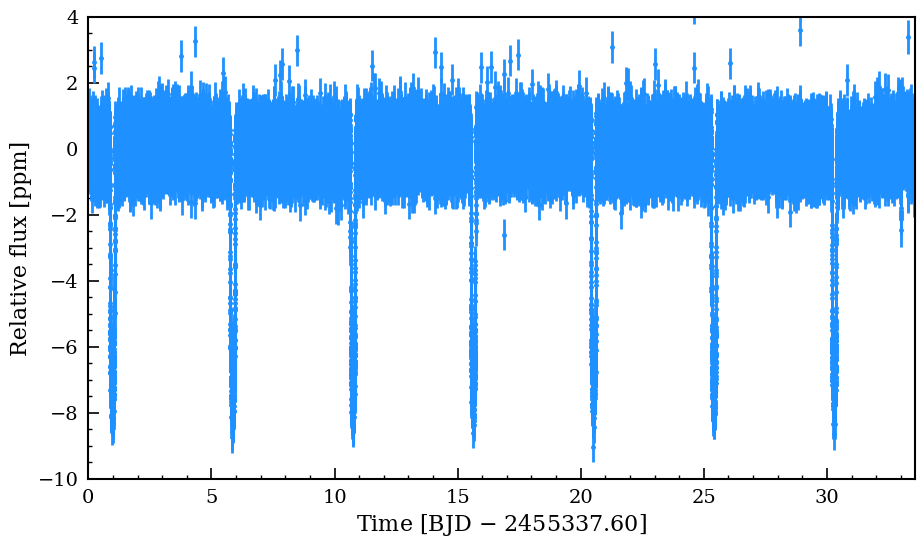

In [3]:
tim5, fl5, fle5 = np.loadtxt(os.getcwd() + '/Data/Kepler-7_Q5.dat',\
                                usecols=(0,1,2), unpack=True)

# Ploting the data
fig, axs = plt.subplots()
axs.errorbar(tim5-tim5[0], (fl5-1)*1e3, yerr=fle5*1e3, fmt='.', color='dodgerblue')
axs.set_xlabel('Time [BJD $-$ {:.2f}]'.format(tim5[0]))
axs.set_ylabel('Relative flux [ppm]')
axs.set_xlim([0., np.max(tim5-tim5[0])])
axs.set_ylim([-10., 4.])

Let's design the priors now. Since we want to fit phase curve model for an inhomogeneously reflective sphere from `kelp`, we will put priors on 5 phase curve parameters (`w0_p1`, `wp_p1`, `agkelp_p1`, `x1_p1`, `x2_p1`). We will iuse `x1`-`x2` parametrisation for the longitudes of the darker region. We will not model any out-of-transit/occultation noise (because there is very little noise in the first place, and it would take long time to model everything with, e.g., Gaussian processes. It is fine to not model extra noise for the purpose of this tutorial.) Note that we are not providing any priors on the occultation time, because we want `juliet` to calculate it self consistently. We will turn on `light_travel_delay` and provide `stellar_radius` in `juliet.fit` to do this.

In [4]:
# Instrument name
instrument = 'Kepler5'

# Creating data dictionaries the way juliet understands
tim, fl, fle = {}, {}, {}
tim[instrument], fl[instrument], fle[instrument] = tim5, fl5, fle5

### Predicting transit and occultation time for our observations
cycle = round((tim5[0] - t0) / per)
tc, tc_err = t0 + cycle*per, np.sqrt(t0_err**2 + (cycle*per_err)**2)
tsec, tsec_err = tc + (per/2), np.sqrt(tc_err**2 + per_err**2)

# Designing priors
## Planetary parameters
par_P = ['P_p1', 't0_p1', 'p_p1', 'b_p1', 'q1_' + instrument, 'q2_' + instrument, 'ecc_p1', 'omega_p1', 'a_p1']
dist_P = ['normal', 'normal', 'uniform', 'uniform', 'uniform', 'uniform', 'fixed', 'fixed', 'loguniform']
hyper_P = [[per, per_err], [tc, tc_err], [0., 1.], [0., 1.], [0., 1.], [0., 1.], 0., 90., [1., 10.]]
## Occultation depth
par_pc = ['w0_p1', 'wp_p1', 'agkelp_p1', 'x1_p1', 'x2_p1']
dist_pc = ['truncatednormal', 'truncatednormal', 'uniform', 'uniform', 'uniform']
hyper_pc = [[0., 0.3, 0., 1.], [0., 0.3, 0., 1.], [0., 0.6], [-90., 25.], [25., 90.]]

## Instrumental priors
par_ins = ['mdilution_' + instrument, 'mflux_' + instrument, 'sigma_w_' + instrument]
dist_ins = ['fixed', 'normal', 'loguniform']
hyper_ins = [1.0, [0., 0.1], [0.1, 10000]]

# Total priors
par_tot = par_P + par_pc + par_ins
dist_tot = dist_P + dist_pc + dist_ins
hyper_tot = hyper_P + hyper_pc + hyper_ins

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And, `juliet` fitting:

**Note that this fitting can take several hours.**

In [5]:
# Output folder
pout = os.getcwd() + '/Analysis/Kelp_inhomo_refl'

# Juliet fitting
data = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle, out_folder=pout)
res = data.fit(sampler='dynamic_dynesty', nthreads=14, light_travel_delay=True, stellar_radius=2.028)

Detected dynamic_dynesty sampler output files --- extracting from /Users/jaspa/Documents/Codes/juliet-examples/Analysis/Kelp_inhomo_refl/_dynesty_DNS_posteriors.pkl


In order to plot the results, we first want to generate all models (i.e., full fitted model, planetary component, etc.) and detrended data.

In [6]:
# --------------------------------------------
#    Some planetary models
# --------------------------------------------
## Mflux and sigma_w (white noise)
mflx = res.posteriors['posterior_samples']['mflux_' + instrument]
sigw = np.nanmedian(res.posteriors['posterior_samples']['sigma_w_' + instrument] * 1e-6)
P_post = np.nanmedian(res.posteriors['posterior_samples']['P_p1'])
t0_post = np.nanmedian(res.posteriors['posterior_samples']['t0_p1'])

# --------------------------------------------
#    Extracting all models
# --------------------------------------------
# Creating all models
model = res.lc.evaluate(instrument, nsamples=5000, return_err=True, return_components=True, return_samples=True)
## Saving all models
all_models = res.lc.model[instrument]

# --------------------------------------------
#    Full fitted models
# --------------------------------------------
# Full fitted model:
full_median_model = model[1]
## Sample random full model (to show uncertainties)
sample_models = model[0]
idx_nsamps = np.random.choice( np.arange(sample_models.shape[0]), size=100, replace=False)
random_models = sample_models[idx_nsamps, :]

# --------------------------------------------
#    Detrended data
# --------------------------------------------
## F1 and F2 factors (F2=0 for this case since mdilution is fixed to 1)
## See, juliet paper to find their meanings
F1 = np.nanmedian( 1 / ( 1 + mflx ) )
F2 = 0.

# Detrended data and errors
detrended_data = fl5 / F1 
detrended_errors = np.sqrt( fle5**2 + sigw**2 )
# Orbital phases (for phase curve)
phases = juliet.utils.get_phases(t=tim5, P=P_post, t0=t0_post, phmin=0.8)

# --------------------------------------------
#    Detrended models
# --------------------------------------------
# Detrended model (we only want to see changes due to planetary parameters so we will fix other params)
post_samps_new = res.posteriors['posterior_samples'].copy()
for i in post_samps_new.keys():
    if ( i[0:5] == 'mflux' ) or ( i[0:9] == 'mdilution' ) or ( i[0:5] == 'theta' ) or ( i[0:2] == 'GP' ):
        post_samps_new[i] = np.zeros(len(post_samps_new[i]))

planet_only_models = res.lc.evaluate(instrument, nsamples=5000, return_err=True, parameter_values=post_samps_new,\
                                     return_components=True, return_samples=True, evaluate_transit=True)

# Sorting indices according to orbital phases
idx_phs = np.argsort(phases)

# Detrended median model
detrended_median_model = planet_only_models[1][idx_phs]
## Corresponding phases
phases_of_detrended_model = phases[idx_phs]
## Random models to show uncertainties
sample_pl_models = planet_only_models[0][:, idx_phs]
idx_nsamps_pl = np.random.choice( np.arange(sample_pl_models.shape[0]), size=100, replace=False)
random_pl_models = sample_pl_models[idx_nsamps_pl, :]

# --------------------------------------------
#    Binned data for visuals
# --------------------------------------------
# Residuals and binned data
resids = fl5 - full_median_model

# Binned data (for phase curves)
bin_phs, bin_det, bin_deterr = juliet.utils.bin_data(x=phases[idx_phs], y=detrended_data[idx_phs], n_bin=2500, yerr=detrended_errors[idx_phs])
_, bin_res, bin_reserr = juliet.utils.bin_data(x=phases[idx_phs], y=resids[idx_phs], n_bin=2500, yerr=detrended_errors[idx_phs])

And plotting:

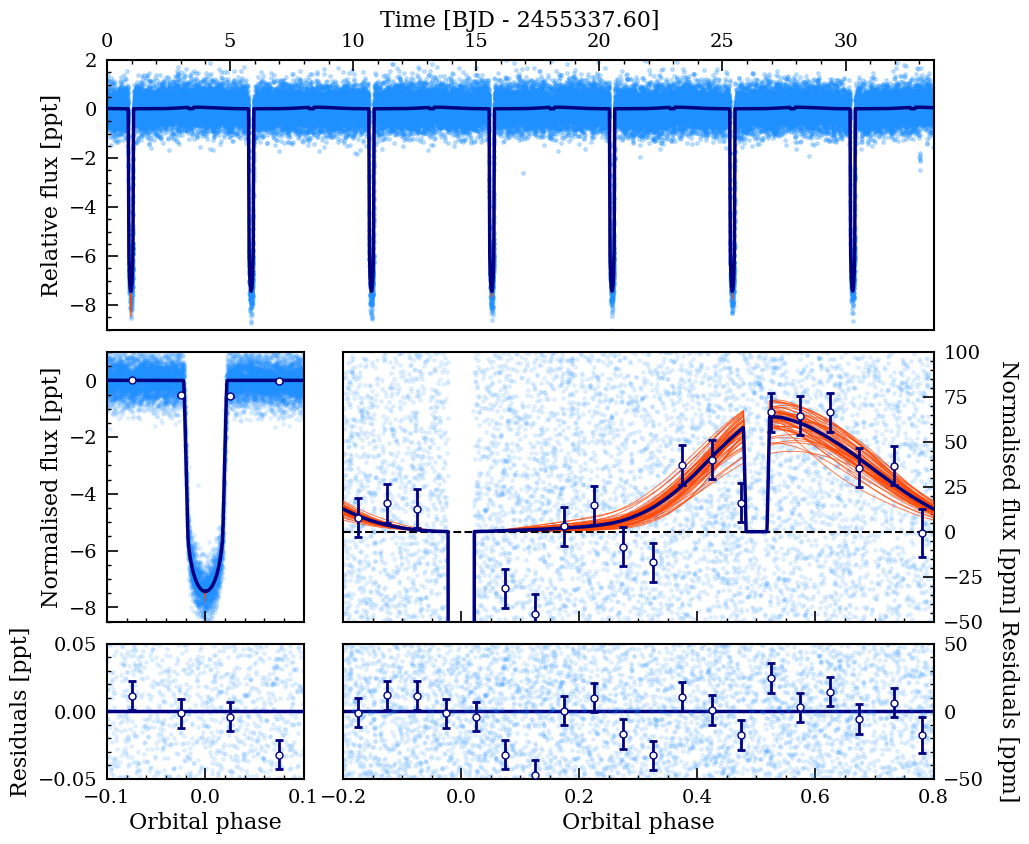

In [7]:
fig = plt.figure(figsize=(16/1.5, 14/1.5))
gs = gd.GridSpec(3, 2, height_ratios=[6,6,3], width_ratios=[1,3], hspace=0.1, wspace=0.1)

ax0 = plt.subplot(gs[0,:])
ax0.errorbar(tim5-tim5[0], (fl5-1.)*1e3, fmt='.', alpha=0.25, c='dodgerblue', zorder=1)
ax0.plot(tim5-tim5[0], (full_median_model-1.)*1e3, c='navy', lw=2.5, zorder=50)
for rand in range(100):
    ax0.plot(tim5-tim5[0], (random_models[rand,:] - 1.)*1e3, color='orangered', alpha=0.7, lw=0.7, zorder=25)

ax0.set_ylabel('Relative flux [ppt]')
ax0.set_xlabel('Time [BJD - {:.2f}]'.format(tim5[0]))
ax0.xaxis.tick_top()
ax0.xaxis.set_label_position('top')
ax0.set_xlim([0., np.max(tim5-tim5[0])])
ax0.set_ylim([-9., 2.])
#ax0.xaxis.set_major_formatter(plt.NullFormatter())

# Transit
xlim1, xlim2 = -0.1, 0.1
## -- Upper panel
ax1 = plt.subplot(gs[1,0])
ax1.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e3, fmt='.', alpha=0.1, c='dodgerblue', zorder=1)
ax1.errorbar(bin_phs, (bin_det-1.)*1e3, yerr=bin_deterr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax1.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e3, color='navy', lw=2.5, zorder=50)
for i in range(50):
    ax1.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e3, color='orangered', alpha=0.5, lw=0.7, zorder=10)

ax1.set_ylabel('Normalised flux [ppt]')
ax1.set_xlim([xlim1, xlim2])
ax1.set_ylim([-8.5, 1.])
ax1.xaxis.set_major_formatter(plt.NullFormatter())

## -- Bottom panel
ax2 = plt.subplot(gs[2,0])
ax2.errorbar(phases_of_detrended_model, resids[idx_phs]*1e3, fmt='.', alpha=0.1, c='dodgerblue')
ax2.errorbar(bin_phs, bin_res*1e3, yerr=bin_reserr*1e3, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=20)
ax2.axhline(0.0, lw=2.5, color='navy', zorder=10)

ax2.set_xlabel('Orbital phase')
ax2.set_ylabel('Residuals [ppt]')
ax2.set_xlim([xlim1, xlim2])
ax2.set_ylim([-0.05, 0.05])


# Phase curve
xlim3, xlim4 = -0.2, 0.8

## Upper panel
ax3 = plt.subplot(gs[1,1])
ax3.errorbar(phases_of_detrended_model, (detrended_data[idx_phs]-1.)*1e6, fmt='.', alpha=0.1, c='dodgerblue', zorder=1)
ax3.errorbar(bin_phs, (bin_det-1.)*1e6, yerr=bin_deterr*1e6, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax3.plot(phases_of_detrended_model, (detrended_median_model-1.)*1e6, c='navy', lw=2.5, zorder=50)
ax3.axhline(0., color='k', ls='--', lw=1.5, zorder=25)
for i in range(50):
    ax3.plot(phases_of_detrended_model, (random_pl_models[i,:]-1.)*1e6, c='orangered', alpha=0.7, lw=0.7, zorder=10)

ax3.set_ylabel('Normalised flux [ppm]', rotation=270, labelpad=25)
ax3.set_xlim([xlim3, xlim4])
ax3.set_ylim([-50., 100.])
ax3.yaxis.tick_right()
ax3.tick_params(labelright=True)
ax3.yaxis.set_label_position('right')
ax3.xaxis.set_major_formatter(plt.NullFormatter())

## Bottom panel
ax4 = plt.subplot(gs[2,1])
ax4.errorbar(phases_of_detrended_model, resids[idx_phs]*1e6, fmt='.', color='dodgerblue', alpha=0.1)
ax4.errorbar(bin_phs, bin_res*1e6, yerr=bin_reserr*1e6, fmt='o', c='navy', elinewidth=2, capthick=2, capsize=3, mfc='white', zorder=100)
ax4.axhline(0., lw=2.5, color='navy')

ax4.set_xlabel('Orbital phase')
ax4.set_ylabel('Residuals [ppm]', rotation=270, labelpad=25)
ax4.set_xlim([xlim3, xlim4])
ax4.set_ylim([-50., 50.])
ax4.yaxis.tick_right()
ax4.tick_params(labelright=True, labelfontfamily='serif')
ax4.yaxis.set_label_position('right')

plt.tight_layout()

The light blue points are the original raw data, while the open blue points are the binned data points. The blue and orange solid lines are the median model and the model calculated from the randomly selected posteriors, respectively. The dashed black line in the middle right corner is the baseline flux level, which is set according to the flux level during an occultation (i.e., at the stellar flux level). The asymmetric shape of the fitted model is clearly seen. There is leftover noise in the data, which can be seen in the binned datapoints. The models calculated from the randomly selected posteriors (in orange) show the uncertainties in the fitted model, which is somewhat larger. This means that we need more data to properly constrain the phase curve. Let's look at the posterior distribution of the phase curve parameters:

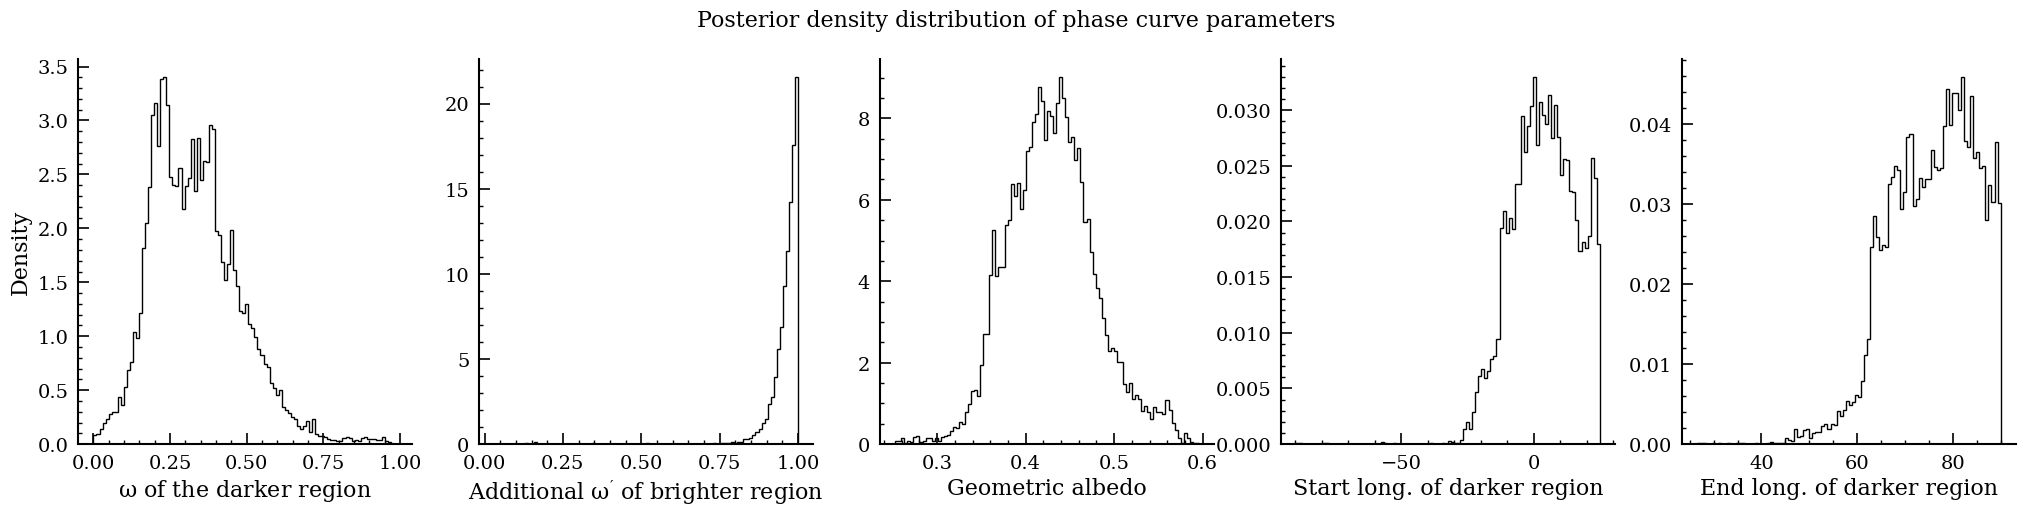

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(25,5))
axs[0].hist(res.posteriors['posterior_samples']['w0_p1'], color='k', bins=100, histtype='step', density=True);
axs[0].set_xlabel(r'$\omega$ of the darker region')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['wp_p1'], color='k', bins=100, histtype='step', density=True);
axs[1].set_xlabel(r'Additional $\omega^\prime$ of brighter region')
#axs[1].set_ylabel('Density')

axs[2].hist(res.posteriors['posterior_samples']['agkelp_p1'], color='k', bins=100, histtype='step', density=True);
axs[2].set_xlabel(r'Geometric albedo')
#axs[2].set_ylabel('Density')

axs[3].hist(res.posteriors['posterior_samples']['x1_p1'], color='k', bins=100, histtype='step', density=True);
axs[3].set_xlabel(r'Start long. of darker region')
#axs[3].set_ylabel('Density')

axs[4].hist(res.posteriors['posterior_samples']['x2_p1'], color='k', bins=100, histtype='step', density=True);
axs[4].set_xlabel(r'End long. of darker region')
#axs[4].set_ylabel('Density')

fig.suptitle('Posterior density distribution of phase curve parameters', fontsize=16)

sns.despine()

They look like fairly constrained (except for maybe start and end longitudes of darker region). Anyway, in the actual analysis, we may want to give more proper priors. Once we have all these planetary phase curves, we can calculate the scattering asymmetry factor and integral phase function:

In [9]:
# Dummy phase range
phs = np.linspace(0., 1., 10000)
## This is because the phases are supposed to be between 0. and 1.
phs = np.sort(phs[1:-1:])

g, q = np.zeros(1000), np.zeros(1000)
aRp = res.posteriors['posterior_samples']['a_p1'] / res.posteriors['posterior_samples']['p_p1']
idx = np.random.choice( np.arange( len(res.posteriors['posterior_samples']['x1_p1']) ), size=1000 )

for i in tqdm(range(1000)):
    _, g[i], q[i] = reflected_phase_curve_inhomogeneous(phases=phases, omega_0=res.posteriors['posterior_samples']['w0_p1'][idx[i]],\
                                                        omega_prime=res.posteriors['posterior_samples']['wp_p1'][idx[i]],\
                                                        x1=res.posteriors['posterior_samples']['x1_p1'][idx[i]],\
                                                        x2=res.posteriors['posterior_samples']['x2_p1'][idx[i]],\
                                                        A_g=res.posteriors['posterior_samples']['agkelp_p1'][idx[i]], a_rp=aRp[idx[i]])

# Computing quantiles
## Scattering asymmetry factor
qua_g = juliet.utils.get_quantiles(g)
g_med, g_up, g_lo = qua_g[0], qua_g[1] - qua_g[0], qua_g[0] - qua_g[2]
## Integral phase function
qua_q = juliet.utils.get_quantiles(q)
q_med, q_up, q_lo = qua_q[0], qua_q[1] - qua_q[0], qua_q[0] - qua_q[2]

print('Geometric albedo: {:.2f} (+{:.2f}) (-{:.2f})'.format(g_med, g_up, g_lo))
print('Integral phase function: {:.2f} (+{:.2f}) (-{:.2f})'.format(q_med, q_up, q_lo))

100%|██████████| 1000/1000 [00:31<00:00, 32.06it/s]

Geometric albedo: -0.76 (+0.07) (-0.06)
Integral phase function: 0.11 (+0.06) (-0.04)


The fitting was actually time consuming -- we may want to look at ways to save times in fitting. There is a way, as described in `kelp_refl_homo.ipynb` and `kelp_thermal.ipynb` notebooks. Instead of calculating phase curve models on each phase point, we can calculate the model on a fixed grid of phases and then interpolate this grid to phases of the data. We can do this by providing number of grid phase points to `kelp_refl_interpolation_knots` keyword argument in `juliet.fit` as shown below:

In [10]:
# Output folder
pout = os.getcwd() + '/Analysis/Kelp_inhomo_refl_inter'

# Juliet fitting
data_inter = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle, out_folder=pout)
res_inter = data_inter.fit(sampler='dynamic_dynesty', nthreads=14, light_travel_delay=True, stellar_radius=2.028,\
                           kelp_refl_interpolation_knots=150)

Detected dynamic_dynesty sampler output files --- extracting from /Users/jaspa/Documents/Codes/juliet-examples/Analysis/Kelp_inhomo_refl_inter/_dynesty_DNS_posteriors.pkl


How does the results from this analysis compare to that from the previous analyses? Let's compare the posterior distribution of phase curve parameters in both cases:

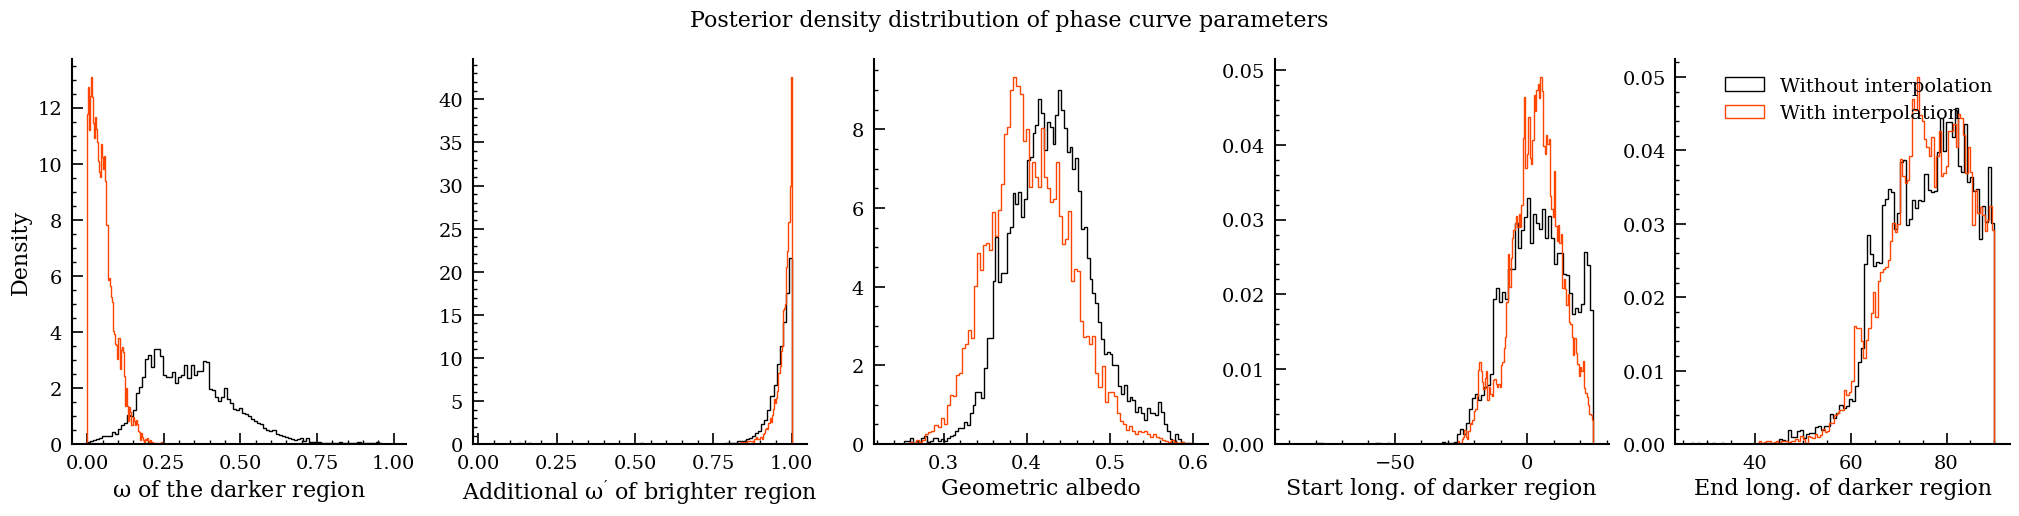

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(25,5))
axs[0].hist(res.posteriors['posterior_samples']['w0_p1'], color='k', bins=100, histtype='step', density=True);
axs[0].hist(res_inter.posteriors['posterior_samples']['w0_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[0].set_xlabel(r'$\omega$ of the darker region')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['wp_p1'], color='k', bins=100, histtype='step', density=True);
axs[1].hist(res_inter.posteriors['posterior_samples']['wp_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[1].set_xlabel(r'Additional $\omega^\prime$ of brighter region')
#axs[1].set_ylabel('Density')

axs[2].hist(res.posteriors['posterior_samples']['agkelp_p1'], color='k', bins=100, histtype='step', density=True);
axs[2].hist(res_inter.posteriors['posterior_samples']['agkelp_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[2].set_xlabel(r'Geometric albedo')
#axs[2].set_ylabel('Density')

axs[3].hist(res.posteriors['posterior_samples']['x1_p1'], color='k', bins=100, histtype='step', density=True);
axs[3].hist(res_inter.posteriors['posterior_samples']['x1_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[3].set_xlabel(r'Start long. of darker region')
#axs[3].set_ylabel('Density')

axs[4].hist(res.posteriors['posterior_samples']['x2_p1'], color='k', bins=100, histtype='step', density=True, label='Without interpolation');
axs[4].hist(res_inter.posteriors['posterior_samples']['x2_p1'], color='orangered', bins=100, histtype='step', density=True, label='With interpolation');
axs[4].set_xlabel(r'End long. of darker region')
axs[4].legend()
#axs[4].set_ylabel('Density')

fig.suptitle('Posterior density distribution of phase curve parameters', fontsize=16)

sns.despine()

Well, this is a bit unfortunate that both posteriors are not exactly aligned. My experience with `kelp` thermal phase curve and reflected light phase curve for homogeneously reflected sphere was different. I need to re-run this.

Let's move on for now. As mentioned before there are two parametrisation of the start and end longitudes of the darker region. The first one is that, we can directly provide the start and end longitudes (in degrees, i.e., `x1` and `x2`) of the darker region. We demonstrated this parametrisation above. The second parametrisation is that we can provide priors on $\sin{x_1}$ and $\sin{x_2}$, that is, `x1prime_p1` and `x2prime_p1`. This parametrisation was used by [Morris et al. (2024)](https://ui.adsabs.harvard.edu/abs/2024A%26A...685A.104M/abstract). We demonstrate the use of this parametrisation below:

In [12]:
## Phase curve parameters (note that we used x1prime_p1 and x2prime_p1 instead of x1_p1 and x2_p1)
par_pc = ['w0_p1', 'wp_p1', 'agkelp_p1', 'x1prime_p1', 'x2prime_p1']
dist_pc = ['truncatednormal', 'truncatednormal', 'uniform', 'uniform', 'uniform']
hyper_pc = [[0., 0.3, 0., 1.], [0., 0.3, 0., 1.], [0., 0.6], [-1., 0.35], [0.35, 1.]]

# Total priors
par_tot = par_P + par_pc + par_ins
dist_tot = dist_P + dist_pc + dist_ins
hyper_tot = hyper_P + hyper_pc + hyper_ins

priors = juliet.utils.generate_priors(params=par_tot, dists=dist_tot, hyperps=hyper_tot)

And `juliet` fitting:

In [13]:
# Output folder
pout = os.getcwd() + '/Analysis/Kelp_inhomo_refl_inter_morris_param'

# Juliet fitting
data_m24 = juliet.load(priors=priors, t_lc=tim, y_lc=fl, yerr_lc=fle, out_folder=pout)
res_m24 = data_m24.fit(sampler='dynamic_dynesty', nthreads=14, light_travel_delay=True, stellar_radius=2.028)

Detected dynamic_dynesty sampler output files --- extracting from /Users/jaspa/Documents/Codes/juliet-examples/Analysis/Kelp_inhomo_refl_inter_morris_param/_dynesty_DNS_posteriors.pkl


Let's compare the posterior of the phase curve parameters from this analysis with the previous analysis:

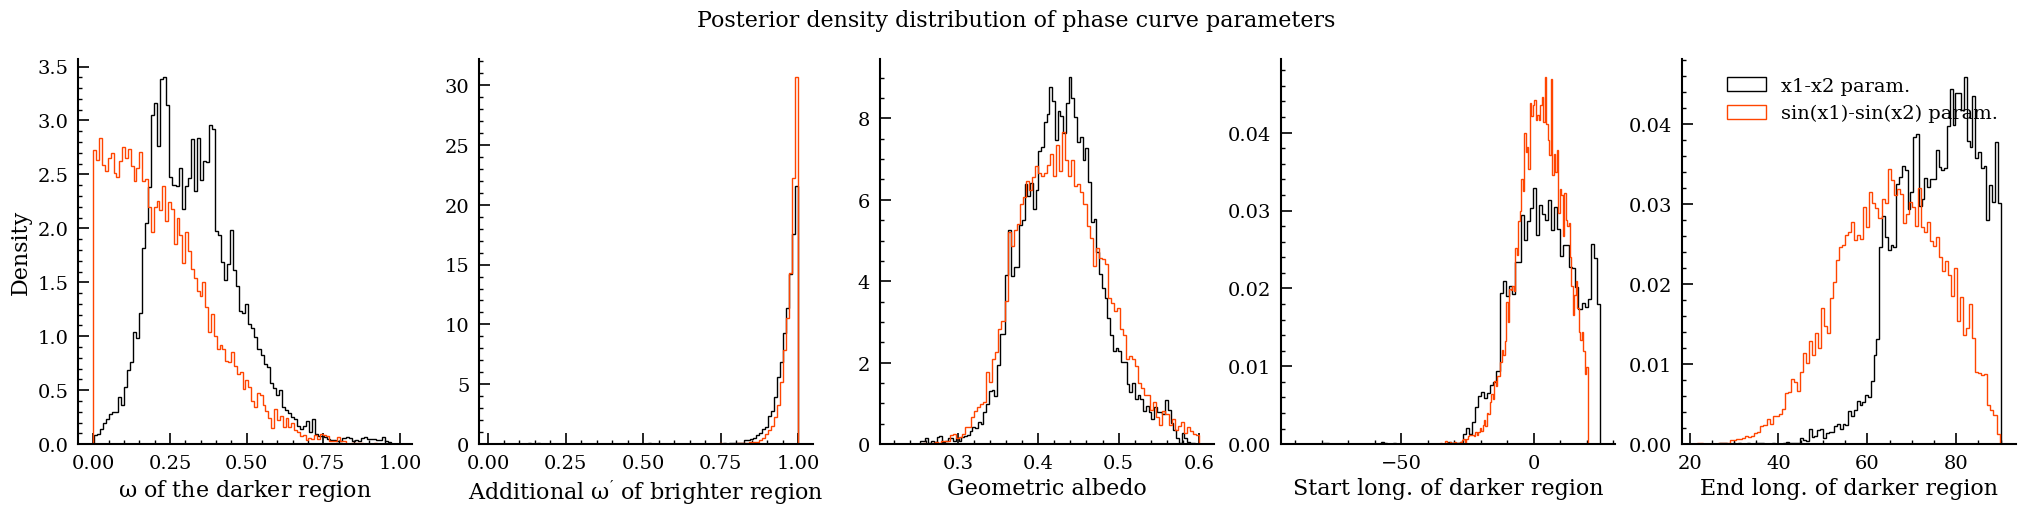

In [14]:
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(25,5))
axs[0].hist(res.posteriors['posterior_samples']['w0_p1'], color='k', bins=100, histtype='step', density=True);
axs[0].hist(res_m24.posteriors['posterior_samples']['w0_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[0].set_xlabel(r'$\omega$ of the darker region')
axs[0].set_ylabel('Density')

axs[1].hist(res.posteriors['posterior_samples']['wp_p1'], color='k', bins=100, histtype='step', density=True);
axs[1].hist(res_m24.posteriors['posterior_samples']['wp_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[1].set_xlabel(r'Additional $\omega^\prime$ of brighter region')
#axs[1].set_ylabel('Density')

axs[2].hist(res.posteriors['posterior_samples']['agkelp_p1'], color='k', bins=100, histtype='step', density=True);
axs[2].hist(res_m24.posteriors['posterior_samples']['agkelp_p1'], color='orangered', bins=100, histtype='step', density=True);
axs[2].set_xlabel(r'Geometric albedo')
#axs[2].set_ylabel('Density')

axs[3].hist(res.posteriors['posterior_samples']['x1_p1'], color='k', bins=100, histtype='step', density=True);
axs[3].hist(np.rad2deg(np.arcsin(res_m24.posteriors['posterior_samples']['x1prime_p1'])), color='orangered', bins=100, histtype='step', density=True);
axs[3].set_xlabel(r'Start long. of darker region')
#axs[3].set_ylabel('Density')

axs[4].hist(res.posteriors['posterior_samples']['x2_p1'], color='k', bins=100, histtype='step', density=True, label='x1-x2 param.');
axs[4].hist(np.rad2deg(np.arcsin(res_m24.posteriors['posterior_samples']['x2prime_p1'])), color='orangered', bins=100, histtype='step', density=True, label='sin(x1)-sin(x2) param.');
axs[4].set_xlabel(r'End long. of darker region')
axs[4].legend()
#axs[4].set_ylabel('Density')

fig.suptitle('Posterior density distribution of phase curve parameters', fontsize=16)

sns.despine()

Great! Most of the phase curve parameters agree well with each other!